# Dataset Sintético

### Generador de dataset

In [ ]:
from sklearn.datasets import make_blobs
import numpy as np

# Generar un número aleatorio de centroides entre 1 y 20
n_centroids = np.random.randint(1, 21)

# Generar coordenadas para los centroides con una dispersión significativa
centroid_min_coord = -20
centroid_max_coord = 20

blob_centers = np.random.uniform(low=centroid_min_coord, high=centroid_max_coord, size=(n_centroids, 2))

blob_std = np.random.uniform(low=0.5, high=10.0, size=n_centroids)

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Dataset generado con {n_centroids} centroides.")
print("Primeras 5 filas de X:")
print(X[:5])
# Las etiquetas 'y' se generan para la simulación, pero no se usan directamente en el clustering.

Dataset generado con 13 centroides.
Primeras 5 filas de X:
[[ -6.42642358  30.90579248]
 [ -6.08917921  11.43267332]
 [-22.00607609  -8.98674061]
 [  1.6715642    4.36412286]
 [ -1.52646368   4.62941682]]


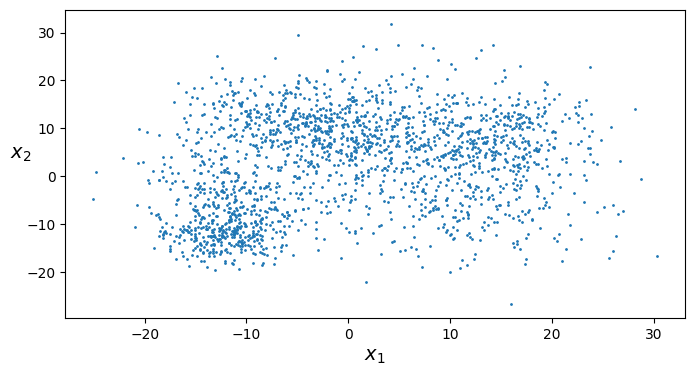

In [ ]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

## Kmeans

### Método del codo

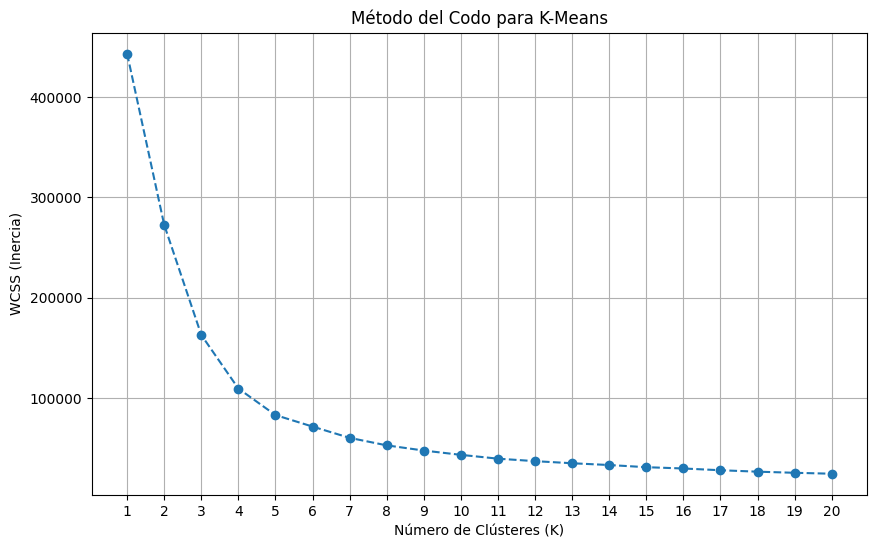

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


wcss = []  # Suma de cuadrados dentro del clúster (Inercia)
possible_k = range(1, 21) # Rango de k a probar: de 1 a 20

for i in possible_k:
    # Ajustamos K-Means para cada 'k' para calcular la inercia
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(possible_k, wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('WCSS (Inercia)')
plt.xticks(possible_k)
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

print("Primeras 5 etiquetas de clúster predichas:")
print(y_pred[:5])

Primeras 5 etiquetas de clúster predichas:
[2 2 1 0 0]


In [ ]:
kmeans.cluster_centers_

array([[ -0.17774435,   0.92491503],
       [-14.40205435,  -9.66824951],
       [ -5.13898874,  15.91666352],
       [-14.99602903,   7.73448498],
       [ 15.30162283, -13.16179466]])

In [ ]:
import numpy as np

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
predictions_new_data = kmeans.predict(X_new)

print("Nuevos puntos de datos:", X_new)
print("Clúster predicho para los nuevos puntos:", predictions_new_data)

Nuevos puntos de datos: [[ 0.   2. ]
 [ 3.   2. ]
 [-3.   3. ]
 [-3.   2.5]]
Clúster predicho para los nuevos puntos: [0 0 0 0]


In [ ]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                cmap="Pastel2")
    plt.contour(xx, yy, Z,
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

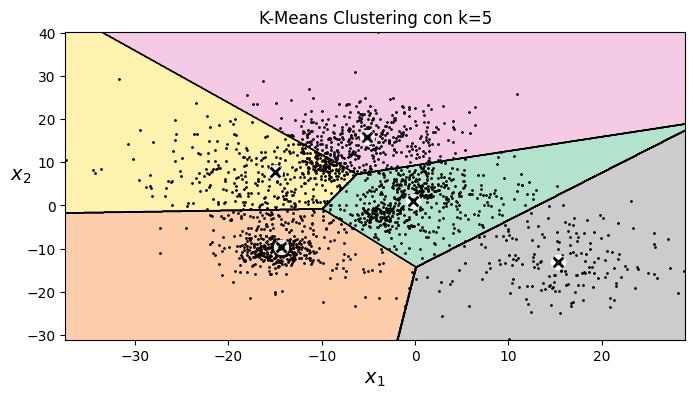

In [ ]:
plt.figure(figsize=(8, 4))
plt.title(f'K-Means Clustering con k={k}')
plot_decision_boundaries(kmeans, X)
plt.show()

In [ ]:
kmeans.transform(X_new)

array([[ 1.0896792 , 18.53556625, 14.8351855 , 16.05506788, 21.541116  ],
       [ 3.35467835, 20.95183864, 16.12193106, 18.88759855, 19.52459837],
       [ 3.50301365, 17.04380794, 13.09257306, 12.8965135 , 24.41624469],
       [ 3.23203026, 16.67552517, 13.58610072, 13.08833624, 24.08819649]])

### Inicialización inteligente con Kmeans

In [ ]:
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)

kmeans_iter2 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

kmeans_iter3 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(algorithm='elkan', max_iter=3, n_clusters=5, n_init=1, random_state=5)

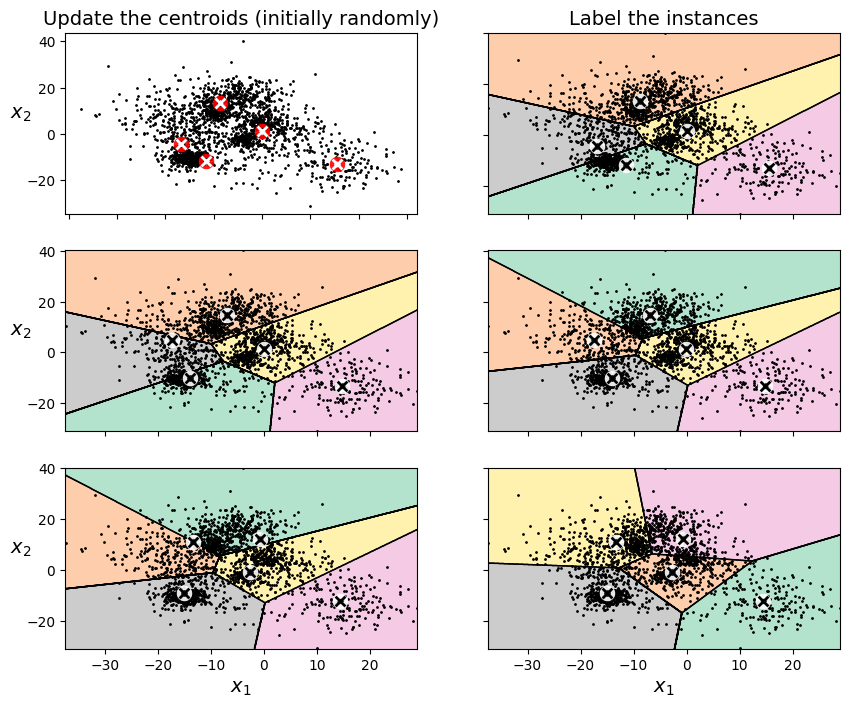

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

In [ ]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

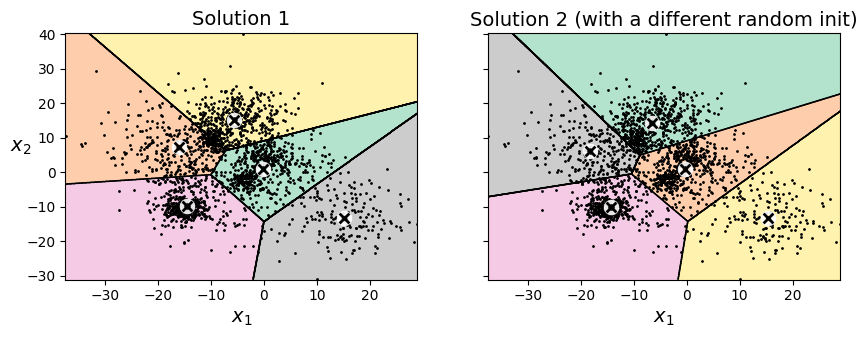

In [ ]:
kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1,
                         algorithm="elkan", random_state=19)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="k-means++", n_init=1,
                         algorithm="lloyd", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

## Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.44839998448094887)

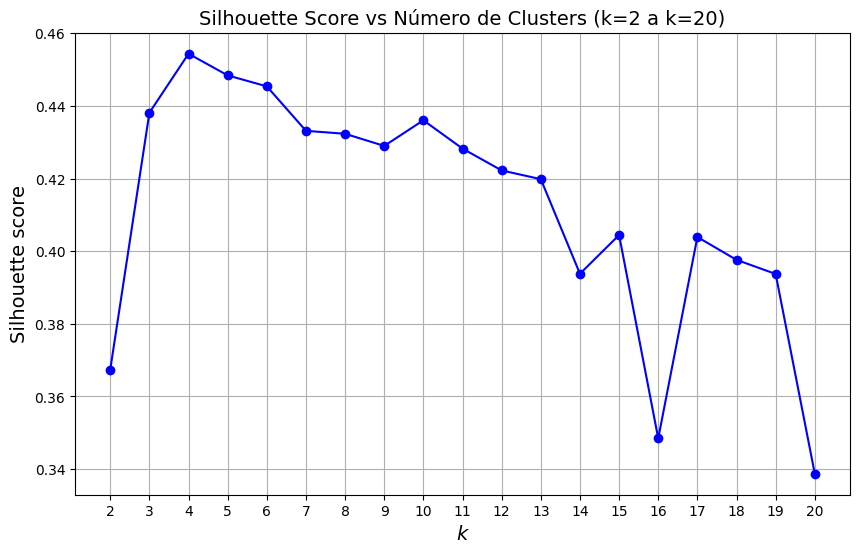

In [ ]:
max_k_silhouette = 20
kmeans_per_k_silhouette = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X) for k in range(1, max_k_silhouette + 1)]

silhouette_scores_range = [silhouette_score(X, model.labels_) for model in kmeans_per_k_silhouette[1:]] # Start from k=2

ks_range = list(range(2, max_k_silhouette + 1))

plt.figure(figsize=(10, 6))
plt.plot(ks_range, silhouette_scores_range, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters (k=2 a k=20)", fontsize=14)
plt.xticks(ks_range)
plt.grid(True)
plt.show()

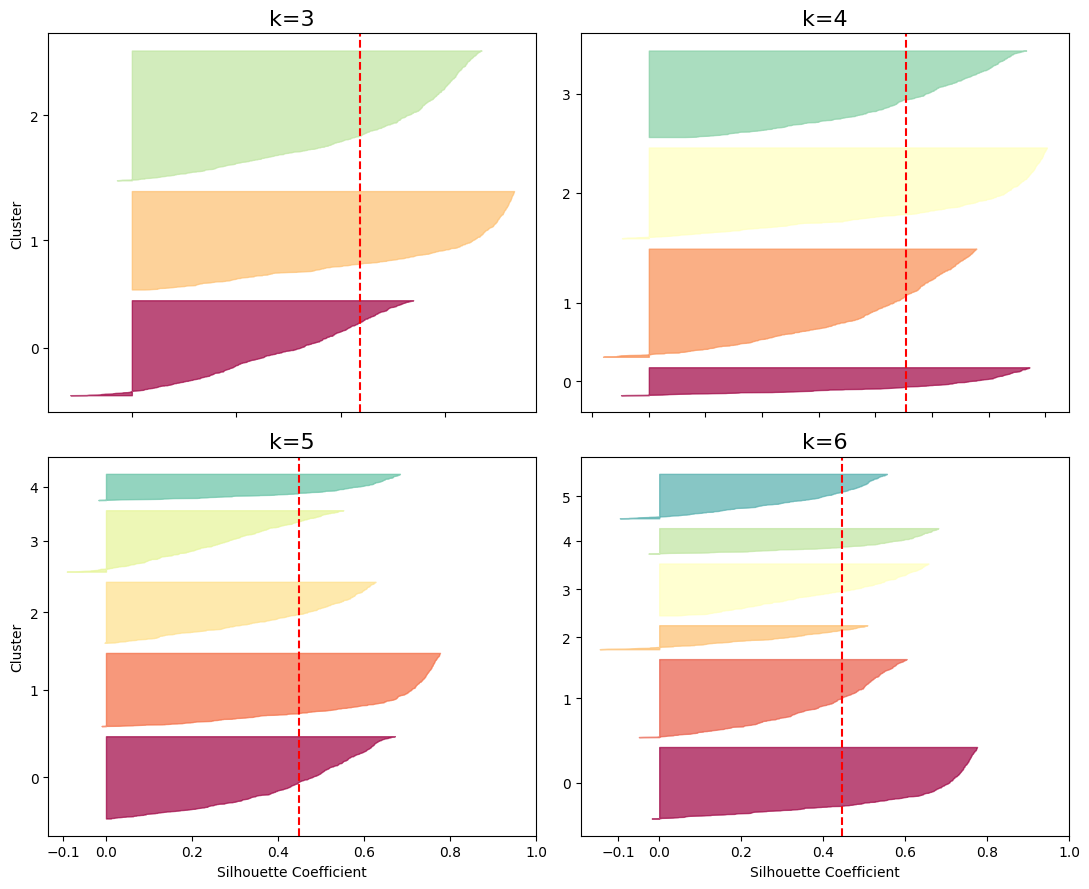

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl
import numpy as np

num_peaks_to_display = 4

sorted_indices = np.argsort(silhouette_scores_range)[::-1]
top_k_indices = sorted_indices[:num_peaks_to_display]

peak_ks = [ks_range[i] for i in top_k_indices]
peak_ks.sort()

plt.figure(figsize=(11, 9))

for plot_idx, k in enumerate(peak_ks):

    if num_peaks_to_display <= 2:
        subplot_rows = 1
        subplot_cols = num_peaks_to_display
    else:
        subplot_rows = 2
        subplot_cols = (num_peaks_to_display + 1) // 2

    plt.subplot(subplot_rows, subplot_cols, plot_idx + 1)

    y_pred = kmeans_per_k_silhouette[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))


    if plot_idx % subplot_cols == 0:
        plt.ylabel("Cluster")

    if plot_idx >= (subplot_rows - 1) * subplot_cols:
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)


    plt.axvline(x=silhouette_scores_range[k - 2], color="red", linestyle="--")
    plt.title(f"k={k}", fontsize=16)

plt.tight_layout()
plt.show()